# ITAD 315 Final Project -- UPS Plane Loader Algorithm

## Problem

**Develop an automated ULD loading order algorithm for UPS cargo planes that satisfies weight balance, hazmat separation, accessibility, and aircraft-specific constraints, reducing manual planning time and potential errors.**

I currently work at UPS loading the planes with ULDs (large containers containing many smaller packages). We have 4 different planes, each with their own weight balances and nuances in loading requirements. ULDs can contain hazardous materials that require further restrictions on placement within the plane based on the material (certain materials must be "accessible" by the crew (load into position 1/2), or loaded to rear, or separated by at least 1 ULD). ULDs must be loaded in a certain order. There are 4 types of ULDs, and only certain planes can load certain ULDs (but some can take all).

Currently, we wait for "Control" to manually determine the load order of the ULDs, and send us the load slip. However, this seems like a solved problem (I'm thinking about NP-Complete problems like Knapsack, Scheduling, and Hamiltonian Path), and think I can create an algorithm to determine load orders based on the various constraints (weight, load restrictions, etc.). Relying on a human to order the load poses the risk of human error (there have been a few incidents where we've loaded a ULD according to their load order, only to have to remove the ULD once the system flags it as invalid (we scan ULDs to "lock" them into position)).

## Solution

Automate the assignment of Unit Load Device (ULD) load order for UPS Boeing 757 cargo aircraft, satisfying all operational constraints for weight distribution, hazmat placement, and regulatory compliance. The solution leverages discrete mathematics and optimization techniques for real-world efficiency gains. Searching all permutations of load orders is not feasible, so an optimization algorithm will need to be designed and implemented. 

![Loading Diagram for Boeing 757](757-loading-diagram.jpg)

## Risks & Mitigations

- Challenge: Problem is NP-hard

  - Mitigation:

    - Start with **Brute Force** algorithm (likely exponential time), for benchmark
    - Use heuristic/approximation algorithms for a **satisficing** strategy
    - Research various ways to structure the problem (ie, graph) and various algorithms that currently exist

- Challenge: **Scope** -- Multiple complex interacting constraints

  - Mitigation: Implement **incrementally**, starting one plane and weight constraints, then adding hazmat rules, and possibly additional planes

- Challenge: Validating correctness

  - Mitigation:

    - Test against known valid load orders from work (borrow load slips, if they're not considered proprietary)
    - Consult my boss for current workflow and solutions
    - Create test cases for edge cases

## Roadmap & Milestones

1. [✔] Gather specific constraints, plane specs, average weight ranges -- then sketch/design graph/data structures
2. [✔] Implement basic algorithm with weight constraints (brute force)
3. [✔] Add hazmat restrictions and other nuances
4. [✔] Design and tweak the optimization algorithm (Monte Carlo Tree Search - MCTS)
4. [✔] Profile MCTS against test data set
5. [ ] Expand profiling to edge cases and alternate ULD configurations
5. [ ] (Stretch) Visualization frontend -- make it look cool, maybe some plane schematics/diagrams to overlay the ULD positions
6. [✔] Prepare writeup and presentation

### Timeline

#### Week 0 -- Nov 12th/13th

Research -- Use AI to gather a comprehensive backstudy on various algorithms, data structures, and optimization strategies. Research my tech stack and available Python libraries, and into various coding principals like Linear Programming.

#### Week 1 -- Nov 14th

Milestones 1 and 2 (gather data and contraints, flesh out data structures, and begin work on brute force algorithm for base case)

#### Week 2 -- Nov 21st

Milestones 2 and 3 (finish brute force algorithm, and iteratively add in additional constraints)

#### Week 3 -- Nov 28th

Milestone 4 (optimize and satisfice the algorithms in an attempt to consistently beat NP time complexity and find best/close to scores)

#### Week 4 -- Dec 1st

Milestone 5 and 6 (finish backlog, perfect the frontend, and prepare the documentation and presentation)

## Relevance to Discrete Mathematics

Ultimately this is a combinatorial problem. We're dealing with permutations and attempting to find the best permutation among them. A brute force solution will search all possible permutations, and any optimization attempt is attempting to search a subspace of that permutation space -- but the algo must **still** be capable of generating the full set of permutations. 

This relates to the class work due to our exposure to combinatorics and recursion, as well my use of a graph structure in the MCTS algorithm.

- **Graph theory** (position modeling)
- **Constraint Satisfaction Problem (CSP)** (constraint handling)
- **Combinotorics** (many combonations of load orders)
- **Complexity theory** (recognizing NP-hardness, justifying heuristic approaches)
- **Optimization algorithms** (beating NP time complexity)

## Algorithm Design

**function** get_best_uld_load_order

**input** ***ulds***: array of ULD objects, ***plane_type***: object of plane specific parameters

**return** ***load_order***: array of sorted ULDs corresponding to plane type load order

### Initial Load Scanning & Knockout

Certain conditions of the total load make the entire load illegal/invalid.

- If total TI > 200
- If total load > plane's max cargo weight
- If total dry ice weight > 6600 pounds

- If total dry ice weight > 2500 pounds, turn on air vents

### Iteration

1. **Generate a permutation of available ULD positions**

1. **Sum all moments:**  
   Total Moment = Σ (Weight × Arm)

2. **Divide by total weight to get loaded CG location:**  
   CG Location = Total Moment ÷ Total Weight

3. **Subtract MAC leading edge location:**  
   CGₘₐc = CG Location − LEMAC

4. **Divide by MAC length for %MAC:**  
   CG(% MAC) = [ CGₘₐc ÷ MAC ] × 100

5. **Compare result to operational and optimal limits:**
   - Target as close as possible to the optimal value **(~32% MAC)** **without exceeding safety/certification limits**.

## Data Structures



In [74]:
plane_types = {
    "747": {},
    "757": {
        "model": "757",
        "loadOrder": [1, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 2, 3],
        # "loadOrder": [1, 10, 9, 8, 7, 6, 5, 4, 2, 3],
        "pivotPosition": 4,
        "maxTakeoffWeight": 255000,  # pounds
        "maxCargoWeight": 72210,  # pounds
        "MAC": 991.9,  # inches aft of datum (159 inches forward of nose)
        "leadingEdgeMAC": 1191.6,  # inches
        "cogEnvelop": [0.07, 0.59],  # percentage of MAC
        "optimalAftCog": 0.32,  # percentage of MAC
        "aftDatumUldStart": 579, # inches aft of datum (datum, plus crew compartment)
        "restrictedUldTypePositions": {
            1: ["A1", "PAG"],
            13: ["A1", "PAG"],
        },
        "prohibitedUldTypes": ["A2"],
        "restrictedHazmatPositions": {
            1: ["M"],
        },
        "accessiblePositions": [1],
    },
    "767": {},
    "MD11": {},
    "A300": {},
}



class ULD:
    def __init__(self, id, tag_id, uld_type, weight, hazmat=[], TI=0.0, dry_ice=0.0):
        self.id = id
        self.tag_id = tag_id
        self.uld_type = uld_type  # e.g., "A1", "LD3"
        self.weight = weight
        self.hazmat = hazmat  # list of hazmat codes
        self.TI = TI  # transport index (radioactive materials)
        self.dry_ice = dry_ice  # pounds of dry ice

        # 125 x 88 x 64 inches for standard LD9+
        self.width = 125
        self.length = 88
        self.height = 64

## Test Data

To test the algorithms and various functions, we'll use a static test set of ULDs:

In [75]:
test_uld_data = [
    # 3 empties
    ULD(id="AAY93810UP", tag_id=None, uld_type="A2", weight=476, hazmat=[], TI=0.0, dry_ice=0.0),
    ULD(id="AAY24592UP", tag_id=None, uld_type="A2", weight=476, hazmat=[], TI=0.0, dry_ice=0.0),
    ULD(id="AAY13278UP", tag_id=None, uld_type="A2", weight=476, hazmat=[], TI=0.0, dry_ice=0.0),

    # Hazmat accessible
    ULD(id="AAY46048UP", tag_id="7198246", uld_type="A2", weight=3619, hazmat=["A"], TI=0.0, dry_ice=0.0),

    # 2 hazmat ["U", "B"]
    ULD(id="AAY42098UP", tag_id="7329258", uld_type="A2", weight=4661, hazmat=["U", "B"], TI=0.0, dry_ice=0.0),
    ULD(id="AAY39256UP", tag_id="7343962", uld_type="A2", weight=3872, hazmat=["U", "B"], TI=0.0, dry_ice=0.0),

    # 1 radioactive ["R"], TI > 20
    ULD(id="AAY28289UP", tag_id="7629903", uld_type="A2", weight=4037, hazmat=["R"], TI=28.5, dry_ice=0.0),

    # Misc other non-hazmat A2 ULDs
    ULD(id="AAY23434UP", tag_id="7731262", uld_type="A2", weight=3232, hazmat=[], TI=0.0, dry_ice=0.0),
    ULD(id="AAY98696UP", tag_id="7127824", uld_type="A2", weight=2718, hazmat=[], TI=0.0, dry_ice=0.0),
    ULD(id="AAY81482UP", tag_id="7688508", uld_type="A2", weight=2902, hazmat=[], TI=0.0, dry_ice=2.5),
    ULD(id="AAY21395UP", tag_id="7308496", uld_type="A2", weight=2839, hazmat=[], TI=0.0, dry_ice=4.6),
    ULD(id="AAY87397UP", tag_id="7850800", uld_type="A2", weight=3413, hazmat=[], TI=0.0, dry_ice=0.0),
    ULD(id="AAY15053UP", tag_id="7585000", uld_type="A2", weight=3860, hazmat=[], TI=0.0, dry_ice=0.0),
    ULD(id="AAY47497UP", tag_id="7487844", uld_type="A2", weight=4247, hazmat=[], TI=0.0, dry_ice=0.0),
    ULD(id="AAY28865UP", tag_id="7804272", uld_type="A2", weight=1394, hazmat=[], TI=0.0, dry_ice=0.0),
]

# 10 - 8, 9, 13, 14, 15 commented out
# 11 - add 15 back in

## Utility Functions

There are several constraints for the plane or specific ULD positioning that require special functions/consideration.

**Radioactive Constraints:** ULD positions are restricted by a ULD's total TI (transport index) that determines how radioactive the contents are, and require separation from the crew or live animals.

In [76]:
import math

radioactive_separation_ranges = [
    # min TI, max TI, separation in inches
    {"min": 0.1, "max": 1.0, "inches": 12},
    {"min": 1.1, "max": 2.0, "inches": 20},
    {"min": 2.1, "max": 3.0, "inches": 28},
    {"min": 3.1, "max": 4.0, "inches": 34},
    {"min": 4.1, "max": 5.0, "inches": 40},
    {"min": 5.1, "max": 6.0, "inches": 46},
    {"min": 6.1, "max": 7.0, "inches": 52},
    {"min": 7.1, "max": 8.0, "inches": 57},
    {"min": 8.1, "max": 9.0, "inches": 61},
    {"min": 9.1, "max": 10.0, "inches": 65},
    {"min": 10.1, "max": 11.0, "inches": 69},
    {"min": 11.1, "max": 12.0, "inches": 73},
    {"min": 12.1, "max": 13.0, "inches": 77},
    {"min": 13.1, "max": 14.0, "inches": 81},
    {"min": 14.1, "max": 15.0, "inches": 85},
    {"min": 15.1, "max": 16.0, "inches": 89},
    {"min": 16.1, "max": 17.0, "inches": 93},
    {"min": 17.1, "max": 18.0, "inches": 97},
    {"min": 18.1, "max": 20.0, "inches": 102},
    {"min": 20.1, "max": 25.0, "inches": 114},
    {"min": 25.1, "max": 30.0, "inches": 126},
    {"min": 30.1, "max": 35.0, "inches": 138},
    {"min": 35.1, "max": 40.0, "inches": 148},
    {"min": 40.1, "max": 45.0, "inches": 157},
    {"min": 45.1, "max": 50.0, "inches": 167},
]


def get_radioactive_separation_distance(uld):
    # Note: uld.TI is the Transport Index of the ULD
    # The first ULD position for 757 is 102 inches aft of crew, 
    # so if uld.TI < 20.0, no separation is needed.
    # TODO: get first ULD position based on plane type
    if uld.TI < 20.0:
        return 0
    elif uld.TI > 50.0:
        return None  # or raise an error 
    for range_data in radioactive_separation_ranges:
        if uld.TI >= range_data["min"] and uld.TI <= range_data["max"]:
            # return range_data["inches"]
            return math.ceil(range_data["inches"] / uld.length)  # return separation in units of ULDs (positions)

## Scoring Function

### COG Calculations

For each ULD, calculate moment about pivot position (referred to as the "datum" all weights are aft of, which is 159 inches in front of the nose of the plane, for a Boeing 757-200), while summing all ULD weights. Final center of gravity is sum of moments / total weight.

To score load order, compare against the optimal aftCog:

- Calculate CG relative to MAC leading edge: `p = plane.leadingEdgeMAC - currentCG`
- Divide by MAC for %MAC, and compare to optimal: `optimalDiff = p / plane.MAC - plane.optimalAftCog`


In [77]:
def is_load_order_valid(uld_load_order, plane_type):
    """
    Check various constraints to determine if a given load order is valid
    - Hazmat restrictions
    - ULD type restrictions
    - Radioactive material separation
    """
    plane_load_order = plane_type["loadOrder"]
    restricted_positions = plane_type["restrictedUldTypePositions"]
    prohibited_uld_types = plane_type["prohibitedUldTypes"]
    restricted_hazmat_positions = plane_type["restrictedHazmatPositions"]

    for pos in plane_load_order:
        uld = uld_load_order[pos-1]
        if uld is None:
            return True  # Allow empty positions

        if uld.uld_type in prohibited_uld_types:
            return False
        
        if "A" in uld.hazmat:
            if pos not in plane_type["accessiblePositions"]:
                return False

        if pos in restricted_positions:
            if uld.uld_type in restricted_positions[pos]:
                return False

        if pos in list(restricted_hazmat_positions.keys()):
            for hazmat_code in uld.hazmat:
                if hazmat_code in restricted_hazmat_positions[pos]:
                    return False
        
        if uld.TI > 0.0:
            separation_needed = get_radioactive_separation_distance(uld)
            if separation_needed is None:
                return False  # TI too high
            else:
                if separation_needed > 0:
                    # Only check for separation before crew for now
                    if pos - 1 - separation_needed < 0:
                        return False
            # Check separation with other ULDs

    return True

def is_uld_set_valid(uld_load_order, plane_type):
    """
    Check if the set of ULDs meet valid meta constraints
    - Total weight within max cargo weight
    - Total TI within limits
    - Dry ice limits
    """
    total_weight = sum(uld.weight for uld in uld_load_order)
    if total_weight > plane_type["maxCargoWeight"]:
        return False

    total_TI = sum(uld.TI for uld in uld_load_order)
    # A plane cannot have over 200.0 total TI of radioactive materials
    if total_TI > 200.0:
        return False

    total_dry_ice = sum(uld.dry_ice for uld in uld_load_order)
    # A plane cannot have over 6600 pounds of dry ice
    if total_dry_ice > 6600.0:
        return False

    return True

def calculate_center_of_gravity(uld_load_order, plane_type):
    """
    Calculate center of gravity for the given load order and plane type.
    Returns COG in inches.
    """
    plane_load_order = plane_type["loadOrder"]
    uldCogStart = plane_type["aftDatumUldStart"]

    def get_total_load_weight(ulds):
        return sum(uld.weight for uld in ulds)
    
    def calc_uld_moment(uld, position):
        # Use ULD position and uld.length to determine moment arm about datum
        # Assume each ULD's center of gravity is at its midpoint
        return uld.weight * (uldCogStart + (position) * uld.length + 0.5 * uld.length)
    
    moments = []
    for pos in plane_load_order:
        moment = calc_uld_moment(uld_load_order[pos-1], pos-1)
        moments.append(moment)
    
    cog = sum(moments) / get_total_load_weight(uld_load_order)
    
    return cog


def score_load_order(load_order, plane_type):
    """
    Score a load order based on the deviation of its center of gravity 
    from the optimal aftCog of the plane (as a percentage of MAC).
    """
    
    cg = calculate_center_of_gravity(load_order, plane_type)
    delta_mac = cg - plane_type["leadingEdgeMAC"]
    score = delta_mac / plane_type["MAC"] - plane_type["optimalAftCog"]
    
    return score

def test_heap_permutation():
    import random
    test_order = test_uld_data[:]
    random.shuffle(test_order)

    score = score_load_order(test_order, plane_types["757"])
    print(f"Test load order score: {score}")

# test_heap_permutation()

## Brute Force -- Heap's Algorithm

The brute force solution for finding the best permutation of an array involves searching the full permutation space, and is **O(n*n!)** in time complexity (`n!` for permutations, and for doing `n` work), and **O(n)** for space complexity (the recursive stack). Heap's algorithm provides a neat and concise way of producing all permutations of an array. It recursively permutes the array by swapping elements in place.

In [78]:
def heap_permute(arr):
    permutations = []
    def permute(arr, k):
        if k == 1:
            permutations.append(arr[:])
        else:
            for i in range(k):
                permute(arr, k - 1)
                if k % 2 == 0:
                    arr[i], arr[k - 1] = arr[k - 1], arr[i]
                else:
                    arr[0], arr[k - 1] = arr[k - 1], arr[0]
    permute(arr, len(arr))
    return permutations

def test_heap_permute():
    # Output: [
    #   [1, 2, 3],
    #   [1, 3, 2],
    #   [2, 1, 3],
    #   [2, 3, 1],
    #   [3, 2, 1],
    #   [3, 1, 2]
    # ]
    arr = [1, 2, 3]
    perms = heap_permute(arr)
    for perm in perms:
        print(perm)

## Implementation -- Brute Force

In [79]:
def find_best_load_order_heap():
    best_score = float('inf')
    best_order = None
    permutations = heap_permute(test_uld_data)
    for perm in permutations:
        score = score_load_order(perm, plane_types["757"])
        if abs(score) < abs(best_score):
            best_score = score
            best_order = perm
    return best_order, best_score

# load_order, score = find_best_load_order_heap()
# print([uld.id for uld in load_order])
# print(f"Best load order score: {score}")

In [80]:
# Helper functions to get weights and load orders from ULD IDs

def get_weights_from_ids(uld_ids, uld_data):
    id_to_uld = {uld.id: uld for uld in uld_data}
    return [id_to_uld[uld_id].weight for uld_id in uld_ids]

def get_load_order_from_ids(uld_ids, uld_data):
    id_to_uld = {uld.id: uld for uld in uld_data}
    return [id_to_uld[uld_id] for uld_id in uld_ids]

best_order_10 = ['AAY46048UP', 'AAY24592UP', 'AAY13278UP', 'AAY93810UP', 'AAY21395UP', 'AAY81482UP', 'AAY87397UP', 'AAY39256UP', 'AAY28289UP', 'AAY42098UP']

best_order_11 = ['AAY46048UP', 'AAY24592UP', 'AAY13278UP', 'AAY93810UP', 'AAY28865UP', 'AAY21395UP', 'AAY81482UP', 'AAY87397UP', 'AAY39256UP', 'AAY28289UP', 'AAY42098UP']



## Optimization -- MCTS

My optimized attempt to determine optimal load orders will utilize the **Monte Carlo Tree Search** (MCTS) algorithm, which builds out the permutation space by testing single "moves" at a time (placing a uld at a position, and building out load orders). It balances its search between novel paths (trying out underscored branches) and high scoring paths with the UCT (upper confidence threshold) heuristic. After each "move", the algorithm "plays out" the remaining positions randomly to estimate a score.

Effectively, I'm treating the plane positions as an empty "game board" and placing ulds like one would move chess peices. If the algorithm was allowed to run to the end, it would build out the full permutation space, approaching **O(n!)**. It would also blow up to **O(n!)** in space complexity, far worse than Heap, because it's now tracking the full game tree in memory (all full length permutations, plus sub-length permutations of each branch). 

In practice, the algorithm is passed a time limit in which to calculate the best move. Typically, in a Chess AI for example, the AI would calculate one move at a time and respond to the other player's next move. In our case, we can simply let it play out the full run, to a depth of the full available positions of the plane. We can also try iteratively running the algo with a time limit for each depth (run for 5 seconds, choose the best next move, then run again for the next best move, etc.). But -- we can also take advantage of this structure to pass it a partial load order as the initial state (for example, perhaps a hazmat ULD of "A" = accessible, must be placed in position 1).

### Algorithm

MCTS breaks down into **four** core stages:

- **SELECTION**: Starting with the root node, recursively select nodes according to the UCT formula until we reach a leaf node or an unexplored node. 
- **EXPANSION**: If the selected node is not a leaf node, create child nodes according to problem logic (available moves/positions). 
- **SIMULATION**: If the expanded node is not a leaf node, perform a "rollout" from that node's state (a random playout) to estimate a score for the node.
- **BACKPROPAGATION**: Bubble up the score through its parents nodes.

### UCT Formula

The UCT formula is used to assess nodes for selection and expansion, balancing novel paths with promising paths. The first term will increase with highly scoring/promising paths, but as the node becomes more frequently explored, is mitigated with second term which increases for highly visited parent nodes with less visited child nodes.

**UCT(j) = w_j / n_j + C * sqrt(ln(N) / n_j)**

Where:
- **w_j** = the number of "wins" or score of the node
- **n_j** = the number of times the node has been visited
- **N** = the number of times the parent node has been visited
- **C** = the exploration coefficient, usually sqrt(2) by default

### Data Structures

The state for nodes will be an array of the length of positions for the plane. The root node will be an array of N `None` values, with the algorithm placing ULDs at various positions in this array. A terminal node will have a fully occupied state.

MCTS best works (or at least, I've always used it with) a graph structure. We're building out a game tree of states and branching from each iteratively as we explore possible paths. So I'm encapsulating the core MCTS logic in a `Node` object, which will initialize the MCTS algorithm.

### Thoughts

I'm thinking to minimize the search space of each depth, that rather than returning **all** possible moves (for all positions), I consider only the possible moves **in order** relative to the plane type (ie, start with position **1**, then position **15**, etc.). 

The value of a node is the sum total of the scores of its children. In Chess, this is simply the number of wins each move generates. However, since we're scoring states with a nobinary value (not 0 or 1), we'll likely need to weight the scores of child nodes by their visits.

We're attempting to find a load order as close to the optimal aft cog value as possible, which means we're minimzing the distance of our value to optimal (and thus, minimizing score). This would require normalization of the scores. Perhaps I minimze the search, or maximize for `1 - norm(score)`?

## Utility Functions

In [81]:
import random

def get_available_positions(arr):
    """Return list of indices where arr has None values"""
    return [i for i, v in enumerate(arr) if v is None]

def get_available_moves(remaining_pieces, load_order):
    """
    Return list of (position, piece) tuples for available moves
    - Considers only moves that produce valid load orders
    """
    available_positions = get_available_positions(load_order)
    moves = []
    for pos in available_positions:
        for piece in remaining_pieces:
            # Only add valid moves to available moves
            potential_load_order = load_order[:]
            potential_load_order[pos] = piece
            if is_load_order_valid(potential_load_order, plane_types["757"]): 
                moves.append((pos, piece))

    # Shuffle moves for randomness in exploration
    if len(moves) != 0:
        random.shuffle(moves)

    # If no valid moves, return None
    return None if len(moves) == 0 else moves

def fill_remaining_positions_greedy(remaining_pieces, load_order):
    """
    'Heaviest Aft' heuristic -- fill heaviest ULDs in the most aft available positions
    1. Get available positions in load order
    2. Sort available positions in reverse order (most aft first)
    3. Sort remaining pieces by weight in descending order
    4. Place heaviest pieces in most aft positions
    5. Return new load order
    """
    available_positions = get_available_positions(load_order)

    # Return None if no valid positions
    if available_positions is None:
        return None
    
    available_positions.sort(reverse=True)
    sorted_pieces = sorted(remaining_pieces, key=lambda uld: uld.weight, reverse=True)

    completion = load_order[:]
    for pos, piece in zip(available_positions, sorted_pieces):
        completion[pos] = piece
    return completion

def fill_remaining_positions_random(remaining_pieces, load_order):
    """Fill remaining positions randomly from remaining pieces"""
    random.shuffle(remaining_pieces)
    completion = load_order[:]
    for pos, piece in zip(get_available_positions(completion), remaining_pieces):
        completion[pos] = piece
    return completion


def uct(w_j, n_j, N, C=math.sqrt(2)):
    """
    Upper Confidence Bound for Trees (UCT) formula
    - w_j: total reward of child node j
    - n_j: number of times child node j has been visited
    - N: total number of times parent node has been visited
    - C: exploration parameter
    """
    if n_j == 0:
        # Capture div0 error and prioritize unvisited nodes
        return float('inf')
    return (w_j / n_j) + C * math.sqrt(math.log(N) / n_j)

def place_accessible_ulds_first(remaining_pieces, load_order, plane_type):
    """
    Place accessible hazmat ULDs in accessible positions before MCTS run
    - Early pruning of search tree of invalid load orders
    TODO: add additional early cases for better pruning
    """
    accessible_positions = plane_type["accessiblePositions"]
    accessible_ulds = [uld for uld in remaining_pieces if "A" in uld.hazmat]
    for pos in accessible_positions:
        if load_order[pos - 1] is None and len(accessible_ulds) > 0:
            uld_to_place = accessible_ulds.pop(0)
            load_order[pos - 1] = uld_to_place
            temp = remaining_pieces[:]
            temp.remove(uld_to_place)
    return temp, load_order

def rollout_policy(state, remaining_pieces, epsilon=0.1):
    """
    Rollout policy for MCTS
    - With probability epsilon, fill remaining positions randomly
    - Otherwise, use greedy 'heaviest aft' heuristic
    Returns a completed state to be scored
    """
    if random.random() < epsilon:
        return fill_remaining_positions_random(remaining_pieces[:], state[:])
    else:
        return fill_remaining_positions_greedy(remaining_pieces[:], state[:])

    

In [ ]:
# Metaparameters

def random_completion_deviations(initial_state, remaining_pieces, n=2000):
    """
    Randomly complete the load order `n` times and record the deviations
    from optimal center of gravity to profile the dataset.
    Called by `profile_data_set`.
    """
    devs = []
    for _ in range(n):
        state = initial_state[:]
        rem = remaining_pieces[:]
        random.shuffle(rem)
        for pos, piece in zip(get_available_positions(state), rem):
            state[pos] = piece
        # Skip invalid load orders
        if not is_load_order_valid(state, plane_types["757"]):
            continue
        dev = abs(score_load_order(state, plane_types["757"]))
        devs.append(dev)
    devs.sort()
    return devs

def profile_data_set(uld_data, plane_type, n=2000):
    """
    Profile the dataset with `n` random completions of load order to find
    deviation statistics to calculate metaparameters and compare MCTS performance.
    - min_dev
    - max_dev
    - median_dev
    """
    remaining_pieces, initial_state = place_accessible_ulds_first(uld_data[:], [None] * len(plane_type["loadOrder"]), plane_type)
    devs = random_completion_deviations(initial_state, remaining_pieces, n=n)

    min_dev = devs[0]
    max_dev = devs[-1]
    median_dev = devs[len(devs)//2]
    # k is a scaling factor for the exponential reward function
    # Set such that a deviation equal to min_dev yields a reward of 0.9
    k = -math.log(0.9) / min_dev

    print(f"Min-dev: {min_dev}, Max-dev: {max_dev}, Median-dev: {median_dev}")
    print(f"k: {k}")

    return min_dev, max_dev, median_dev, k

# Set global metaparameters for current dataset
min_dev, max_dev, median_dev, k = profile_data_set(test_uld_data, plane_types["757"], n=5_000)

# Reward functions based off metaparameters


def reward_from_dev_linear(dev, min_dev=min_dev, max_dev=max_dev, gamma=2.5):
    """
    Use a linear scaling of deviation to compute reward
    in order to map deviation to [0, 1] range,
    where dev is the absolute deviation from optimal center of gravity.
    Returns a reward in [0, 1], where lower deviation yields higher reward,
    with gamma controlling the steepness of the reward curve, creating
    greater impact on UCT for very small deviations.
    """
    r = (max_dev - dev) / (max_dev - min_dev + 1e-9)
    r = min(max(r, 0.0), 1.0)
    return r ** gamma

def compute_reward(error):
    # return math.exp(-k * error)
    return reward_from_dev_linear(error)

def seed_greedy_branch(root, remaining_pieces, load_order):
    """
    Seed the MCTS tree with a greedy branch by filling in the remaining positions
    with the heaviest ULDs in descending order of position.
    """
    available_positions = get_available_positions(load_order)
    available_positions.sort(reverse=True)
    remaining_pieces.sort(key=lambda uld: uld.weight, reverse=True)

    move_sequence = []
    for pos, piece in zip(available_positions, remaining_pieces):
        move_sequence.append((pos, piece))

    node = root
    for move in move_sequence:
        node = node.apply_move(move)

    # Score Greedy terminal node and propagate
    error = abs(score_load_order(node.state, plane_types["757"]))
    reward = compute_reward(error)
    node.backpropagate(reward)
    
    return node # return the terminal greedy node

IndexError: list index out of range

In [ ]:
class Node:
    def __init__(self, state, remaining_pieces, parent=None, action=None):
        self.state = state  # current load order
        self.remaining_pieces = remaining_pieces  # pieces that can still be placed
        self.parent = parent  # parent node
        self.children = []  # list of child nodes
        self.visits = 0  # number of times node was visited
        self.value = 0  # total value of node
        self.action = action  # action taken to reach this node

        self.dead_end = False # Node with incomplete state and no valid moves
        self.dead_ends = 0
        self.greedy_seed = False # Node created during greedy branch seeding

    def is_terminal(self):
        if None not in self.state:
            return True
        if self.dead_end:
            return True
        return False

    def expand(self):
        moves = get_available_moves(self.remaining_pieces, self.state)
        if moves is None:
            # Non-terminal node, but no valid moves -> dead end
            self.dead_end = True
            return self
        for pos, piece in moves:
            new_state = self.state[:]
            new_state[pos] = piece
            new_remaining = self.remaining_pieces[:]
            new_remaining.remove(piece)
            child_node = Node(new_state, new_remaining, parent=self, action=(pos, piece))
            self.children.append(child_node)
        # Return random child for simulation
        return random.choice(self.children)

    def select(self, exploration=0.2):
        # Select child with highest UCT value
        choices_weights = [
            uct(child.value, child.visits, self.visits, exploration) for child in self.children
        ]
        return self.children[choices_weights.index(max(choices_weights))]

    def simulate(self):
        if self.dead_end:
            return 0.0  # worst possible reward for dead end
        rollout_state = rollout_policy(self.state[:], self.remaining_pieces[:])
        error = abs(score_load_order(rollout_state, plane_types["757"]))
        reward = compute_reward(error)
        return reward

    def backpropagate(self, reward):
        self.visits += 1
        self.value += reward
        if reward == 0.0:
            # Track dead ends in tree for profiling
            self.dead_ends += 1
        if self.parent:
            self.parent.backpropagate(reward)

    def apply_move(self, move):
        # For Greedy Branch Seeding
        self.greedy_seed = True
        
        # Create new state from move
        pos, piece = move
        new_state = self.state[:]
        new_state[pos] = piece
        new_remaining = self.remaining_pieces[:]
        new_remaining.remove(piece)

        # Create new child node with updated state and remaining pieces
        child = Node(new_state, new_remaining, parent=self, action=move)
        self.children.append(child)

        return child

def mcts(root, iterations=1000, greedy_terminal_node=None):
    """
    Monte Carlo Tree Search algorithm
    For each iteration it will select and expand a node, building out the search tree.
    After all iterations, it will return the best terminal node found.

    If it didn't have enough time/iterations to build out a full load order branch, it
    will use a greedy fill to complete the load order.
    """
    # Track best terminal node seen, in case we saw a better one but it didn't get enough visits
    # to trigger the greedy select (exploration=0)
    best_terminal_node = greedy_terminal_node if greedy_terminal_node is not None else None
    best_terminal_score = greedy_terminal_node.value if greedy_terminal_node is not None else float('-inf')

    for _ in range(iterations):
        node = root
        # Selection
        while True:
            if node.is_terminal():
                break
            if not node.children:
                # leaf (not expanded yet)
                break
            if node.greedy_seed and len(node.children) == 1:
                # If greedy seed node with unexpanded children, expand
                break
                
            node = node.select()

        # Expansion
        node = node.expand()
        # Simulation
        reward = node.simulate()

        # Track best complete terminal seen during simulations
        if node.is_terminal() and reward > best_terminal_score:
            best_terminal_score = reward
            best_terminal_node = node

        # Backpropagation
        node.backpropagate(reward)

    # return greedy choice
    if best_terminal_node is not None:
        return best_terminal_node
    
    # Search for best terminal node in tree
    node = root
    while node.children and not node.is_terminal():
        node = node.select(exploration=0)

    # If incomplete load order, use greedy fill
    if not node.is_terminal():
        filled_state = fill_remaining_positions_greedy(node.remaining_pieces, node.state)
        node.state = filled_state
        
    return node

def find_best_mcts_load_order(ulds, plane_type, iterations, greedy_heuristic_on=False):
    # Init state with None
    initial_state = [None] * len(plane_type["loadOrder"])

    # Place accessible ULDs before starting MCTS
    remaining_pieces, initial_state = place_accessible_ulds_first(ulds, initial_state, plane_type)
    root = Node(initial_state, remaining_pieces)

    # Seed greedy branch
    if greedy_heuristic_on:
        greedy_terminal_node = seed_greedy_branch(root, remaining_pieces, initial_state)
    else:
        greedy_terminal_node = None

    # Run MCTS
    best_node = mcts(root, iterations, greedy_terminal_node)
    locked_positions = best_node.state

    # Profile Root Stats
    # print(f"Root Visits: {root.visits}, Root Value: {root.value}")
    # print("Dead Ends in Tree:", root.dead_ends)
    # for c in root.children:
    #     print(f"Visits: {c.visits}, Value: {c.value}, Avg Reward: {c.value / c.visits if c.visits > 0 else None}")   
    
    return locked_positions


## Implementation -- MCTS

In [ ]:
def sim_mcts():
    best_mcts_load_order = find_best_mcts_load_order(test_uld_data, plane_types["757"], iterations=50000)
    print(f"Best load order: {[uld.id for uld in best_mcts_load_order]}")
    print(get_weights_from_ids([uld.id for uld in best_mcts_load_order], test_uld_data))
    score = score_load_order(best_mcts_load_order, plane_types["757"])
    print(score)

    return score

# Brute Force
# 10 ulds With restrictions enforced
# ['AAY46048UP', 'AAY24592UP', 'AAY13278UP', 'AAY93810UP', 'AAY21395UP', 'AAY81482UP', 'AAY87397UP', 'AAY39256UP', 'AAY28289UP', 'AAY42098UP']
# Best load order score: -0.39432654541003664

# 11 ulds with restrictions = 3m 1.0s
# ['AAY46048UP', 'AAY24592UP', 'AAY13278UP', 'AAY93810UP', 'AAY28865UP', 'AAY21395UP', 'AAY81482UP', 'AAY87397UP', 'AAY39256UP', 'AAY28289UP', 'AAY42098UP']
# [3619, 476, 476, 476, 1394, 2839, 2902, 3413, 3872, 4037, 4661]
# Best load order score: -0.33302605068747243

scores = []
for _ in range(1):
    scores.append(sim_mcts())

for score in scores:
    print(f"MCTS Load Order Score: {score}")

Best load order: ['AAY46048UP', 'AAY93810UP', 'AAY24592UP', 'AAY13278UP', 'AAY28865UP', 'AAY98696UP', 'AAY21395UP', 'AAY81482UP', 'AAY23434UP', 'AAY15053UP', 'AAY87397UP', 'AAY39256UP', 'AAY28289UP', 'AAY47497UP', 'AAY42098UP']
[3619, 476, 476, 476, 1394, 2718, 2839, 2902, 3232, 3860, 3413, 3872, 4037, 4247, 4661]
-0.12503566262979462
MCTS Load Order Score: -0.12503566262979462


## Profiling

To assess the health of the MCTS algorithm, we'll profile it against the brute force algorithm for 10 and 11 ULD configurations for various scenarios and edge cases, at various iteration counts (how many times the MCTS searches and expands in the tree), and while toggling the Greedy Load heuristic (seed the tree with the greedy load order). Because brute force is not feasible for greater than 11 ULDs, we default to the greedy load order for "best score" estimate (loading heaviest aft). 

In [ ]:
import time
import json
# Number to run set of iterations
meta_iterations = 10

base_iterations, max_iterations, step = 10_000, 100_000, 10_000

def profile_mcts_iterations():
    def write_results_to_json(filename, results):
        with open(filename, 'w') as f:
            json.dump(results, f, indent=2)

    def run_iterations(iterations, greedy_heuristic_on):
        times = []
        scores = []
        
        for _ in range(meta_iterations):
            start_time = time.time()
            best_mcts_load_order = find_best_mcts_load_order(
                test_uld_data, 
                plane_types["757"], 
                iterations=iterations, 
                greedy_heuristic_on=greedy_heuristic_on
            )
            end_time = time.time()
            
            times.append(end_time - start_time)
            score = score_load_order(best_mcts_load_order, plane_types["757"])
            scores.append(abs(score))
        
        return times, scores

    greedy_on_results = {}
    greedy_off_results = {}
    greedy_on_times = {}
    greedy_off_times = {}

    for iterations in range(base_iterations, max_iterations + 1, step):
        # Run with greedy heuristic on
        greedy_on_times[iterations], greedy_on_results[iterations] = run_iterations(iterations, True)
        
        # Run with greedy heuristic off
        greedy_off_times[iterations], greedy_off_results[iterations] = run_iterations(iterations, False)

    write_results_to_json("results.json", {
        "greedy_on_results": greedy_on_results,
        "greedy_off_results": greedy_off_results,
        "greedy_on_times": greedy_on_times,
        "greedy_off_times": greedy_off_times
    })

    return greedy_on_results, greedy_off_results, greedy_on_times, greedy_off_times

# greedy_on_results, greedy_off_results, greedy_on_times, greedy_off_times = profile_mcts_iterations()


In [ ]:
# Plot results
import matplotlib.pyplot as plt
import numpy as np
import json

def profile_deviation(results, best_score):
    """
    Compute average deviation from the best score for each iteration count.
    """
    def plot_deviation_profile(dev_profile):
        x = sorted(dev_profile.keys())
        y = [dev_profile[k] for k in x]
        plt.plot(x, y, marker='o')

        # Add horizontal reference lines
        min_dev, max_dev, median_dev, k = profile_data_set(test_uld_data, plane_types["757"], n=5_000)
        plt.axhline(y=min_dev, color='green', linestyle='--', label=f'Min Deviation: {min_dev:.2f}')
        plt.axhline(y=max_dev, color='red', linestyle='--', label=f'Max Deviation: {max_dev:.2f}')
        plt.axhline(y=median_dev, color='orange', linestyle='--', label=f'Median Deviation: {median_dev:.2f}')
        plt.axhline(y=best_score, color='blue', linestyle='-', linewidth=2, label=f'Best Score (Greedy): {best_score:.2f}')
        

        plt.xlabel('Iteration Count')
        plt.ylabel('Average Deviation from Best Score')
        plt.title('Average Deviation vs. Iteration Count')
        plt.legend()
        plt.grid(True)
        plt.show()

    dev_profile = {}
    for iter_count, scores in results.items():
        avg_dev = np.mean([abs(s) for s in scores])
        dev_profile[iter_count] = avg_dev

    plot_deviation_profile(dev_profile)
    return dev_profile


def plot_results(results, title, best_score):
    brute_force_score = abs(best_score)
    iterations = []
    scores = []

    for it, score_list in results.items():
        iterations.extend([it] * len(score_list))
        scores.extend(score_list)

    iterations = np.array(iterations)
    scores = np.array(scores)

    unique_iters = np.array(sorted(results.keys()))
   
    # Count how many times the best score was found per iteration count
    best_count = []
    for it in unique_iters:
        scores_this_iter = np.array(results[it])
        hits = np.sum(scores_this_iter <= brute_force_score)
        best_count.append(hits)

    best_count = np.array(best_count)


    fig, ax_score = plt.subplots(figsize=(10, 5))
    
    # Left: scores as scatter
    ax_score.scatter(iterations, scores, s=20, color='tab:blue', alpha=0.7)
    ax_score.set_xlabel("Iteration")
    ax_score.set_ylabel("Score", color='tab:blue')
    ax_score.tick_params(axis='y', labelcolor='tab:blue')
    
    # Horizontal line for brute-force best
    ax_score.axhline(
        y=brute_force_score,
        color='tab:blue',
        linestyle='--',
        linewidth=1,
        label='Brute-force best'
    )
    
    # Right: # times best score found (bars)
    ax_best = ax_score.twinx()
    ax_best.bar(
        unique_iters,
        best_count,
        width=(unique_iters[1] - unique_iters[0]) * 0.8 if len(unique_iters) > 1 else 100,
        color='tab:orange',
        alpha=0.3,
        label='# times best score found'
    )
    ax_best.set_ylabel("# times best score found", color='tab:orange')
    ax_best.tick_params(axis='y', labelcolor='tab:orange')
    
    ax_score.set_xticks(unique_iters)
    
    ax_best.set_yticks(range(0, 11))
    ax_best.set_ylim(0, 10)

    lines_labels = ax_score.get_legend_handles_labels()
    bars_labels = ax_best.get_legend_handles_labels()
    handles = lines_labels[0] + bars_labels[0]
    labels = lines_labels[1] + bars_labels[1]
    ax_score.legend(handles, labels, loc='upper left')
    
    plt.tight_layout()
    fig.suptitle(title, fontsize=14)
    plt.show()

# Plot Times
def plot_times(times_dict, title):
    iterations = []
    times = []

    for it, time_list in times_dict.items():
        iterations.extend([it] * len(time_list))
        times.extend(time_list)

    iterations = np.array(iterations)
    times = np.array(times)

    unique_iters = np.array(sorted(times_dict.keys()))
    avg_times = [np.mean(times_dict[it]) for it in unique_iters]

    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.scatter(iterations, times, s=20, color='tab:green', alpha=0.7)
    ax.plot(unique_iters, avg_times, color='tab:red', linewidth=2, label='Average Time')
    
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Time (seconds)", color='tab:green')
    ax.tick_params(axis='y', labelcolor='tab:green')
    
    ax.set_xticks(unique_iters)
    
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    fig.suptitle(title, fontsize=14)
    plt.show()

def load_profiling_results(filepath='results.json'):
    with open(filepath, 'r') as f:
        results = json.load(f)
    
    # Convert string keys back to integers
    greedy_on_results = {int(k): v for k, v in results['greedy_on_results'].items()}
    greedy_off_results = {int(k): v for k, v in results['greedy_off_results'].items()}
    greedy_on_times = {int(k): v for k, v in results['greedy_on_times'].items()}
    greedy_off_times = {int(k): v for k, v in results['greedy_off_times'].items()}
    
    return greedy_on_results, greedy_off_results, greedy_on_times, greedy_off_times




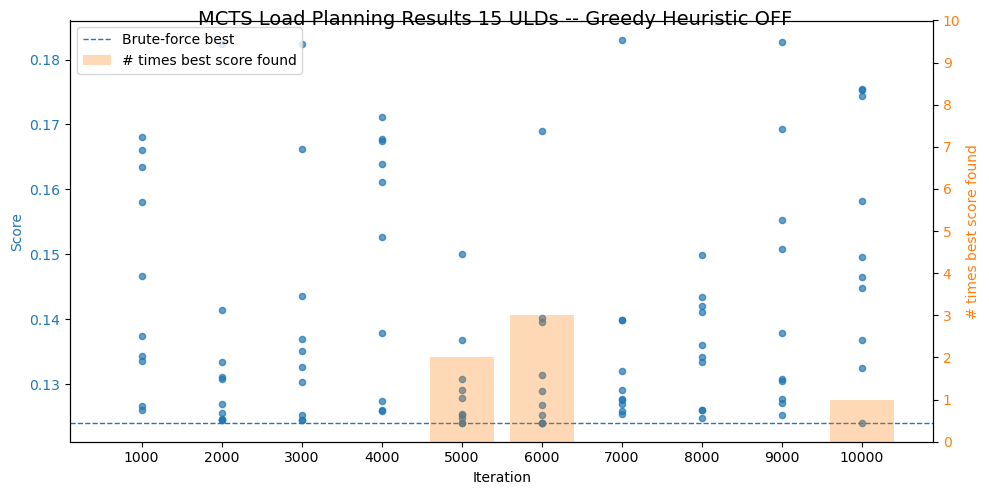

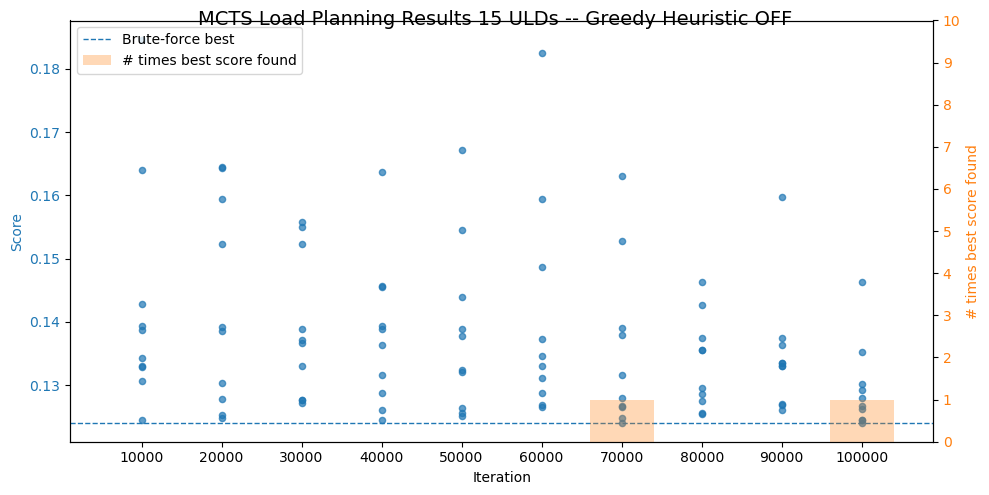

Min-dev: 0.1475546683476981, Max-dev: 0.41105035902839904, Median-dev: 0.28128608571358743
k: 0.7140439325820215


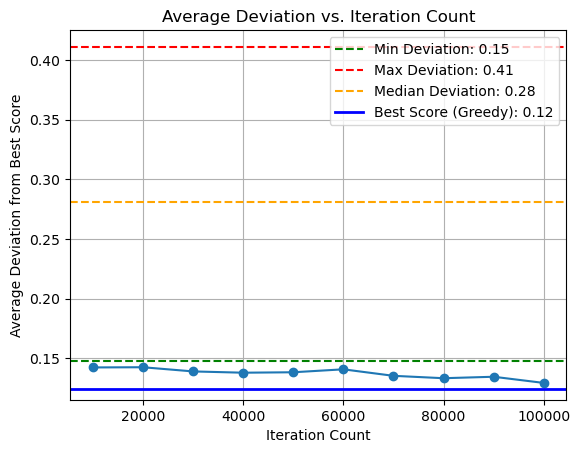

{10000: np.float64(0.14247848900522248),
 20000: np.float64(0.14263923398398695),
 30000: np.float64(0.13913940605418018),
 40000: np.float64(0.13806251975853537),
 50000: np.float64(0.13843275852008194),
 60000: np.float64(0.14089877560606973),
 70000: np.float64(0.13545550936437628),
 80000: np.float64(0.13344882368176006),
 90000: np.float64(0.13466859440297343),
 100000: np.float64(0.12950059080465454)}

In [ ]:
# Plot our results

# Calculate greedy baseline
remaining_ulds, initial_state = place_accessible_ulds_first(test_uld_data, [None]*len(plane_types["757"]["loadOrder"]), plane_types["757"])
greedy_load_order = fill_remaining_positions_greedy(remaining_ulds, initial_state)
greedy_score = score_load_order(greedy_load_order, plane_types["757"])

greedy_on_results, greedy_off_results, greedy_on_times, greedy_off_times = load_profiling_results("results-1000.json")
plot_results(greedy_off_results, "MCTS Load Planning Results 15 ULDs -- Greedy Heuristic OFF", greedy_score)
# plot_results(greedy_on_results, "MCTS Load Planning Results 15 ULDs -- Greedy Heuristic ON", greedy_score)
# plot_times(greedy_off_times, "MCTS Load Planning Times -- Greedy Heuristic OFF")

greedy_on_results, greedy_off_results, greedy_on_times, greedy_off_times = load_profiling_results("results-10000.json")
plot_results(greedy_off_results, "MCTS Load Planning Results 15 ULDs -- Greedy Heuristic OFF", greedy_score)
# plot_results(greedy_on_results, "MCTS Load Planning Results 15 ULDs -- Greedy Heuristic ON", greedy_score)
# plot_times(greedy_off_times, "MCTS Load Planning Times -- Greedy Heuristic OFF")

profile_deviation(greedy_off_results, abs(greedy_score))

## Frontend

Incomplete...

## Reflection

### Summary

The MCTS algorithm generally finds load orders within 5% of the optimal aft cog value (for low iterations, 1000-5000), and about 2% for higher iterations, discovering the best (brute force solution) about 20% of the time (for 11 ULDs), and < 10% for 15 ULDs. At 50,000 iterations on 15 ULDs, I was getting within 0.1% of optimal.

When plotting the mean deviations (scores) of each iteration count, and comparing them against the min_dev, max_dev, median of the dataset (via random completions), we see that the mean scores of MCTS consistently score between min_dev and the best_score. So, although we're not consistently finding the best score, we're always performing better than the best random output.

The time of the algorithm scales linearly with the number of iterations used (how many times we run the MCTS algo: how many nodes of the search tree are expanded and explored). As the search space increases factorially with the number of ULD positions, to maintain accuracy of the MCTS algo, we need to increase the iteration count (to explore reasonable portions of the search space). 

For reference: 
- 5,000 iterations was sufficient for 10 ULDs (3,628,800 permutations) = 2.1 seconds
- 10,000 for 11 ULDs (39,916,800) = 11.8 seconds
- 50,000 for 15 (1,307,674,368,000) = 35.0 seconds

Brute Force times:
- 10! = 12.8 seconds
- 11! = 3 mins 1 second
- 15! = 60.5 days

For 10 and 11 ULD configurations, I can run brute force to compare MCTS to the true best score. However, higher than that and I truly don't know what the best score is. However, it appears that simply loading the plane heaviest to lightest, starting aft, has consistently produced the best possible score. So I use this score to compare at higher ULD counts. 

### Implementation

Due to time constraints, I only implemented features for the Boeing 757-200. The basic implementation of position restrictions was straightforward, and simply hand-coded rules. I used a basic set of ULD test data to run and profile the algorithms against for consistency.

#### Major Pivots

Originally, I had intended to create a graph of connected nodes represented each ULD with edges to ULDs it could be legally placed adjacent to. I would then path through this graph, effectively a Hamiltonian path or Travelling Saleman Problem. Once I sat down and really analyzed the problem, I realized there weren't enough constraints to justify a graph structure (it would have just been a highly connected graph). If there were enough constraints to create a sparser graph, then this may have been an interesting approach. So I abandoned the intended graph structure and pathing for the graph tree structure for the MCTS. 

Once I began designing the MCTS algorithm, I realized I had to pivot hard in my initial approach. While position restrictions turned out to be easy to implement, I spent an immense amount of time troubleshooting MCTS and tweaking metaparameters, which was my core **technical difficulty** in this project. The initial design was performing no better than random, it seemed. After pivots 1 and 2, I turned to AI to help me troubleshoot and debug -- I needed an MCTS expert. After describing the behavior of my algorithm, providing stats and code snippets, we incrememntally tackled various elements and implementations. I learned that I did _not_ have as strong a grasp on the MCTS algorithm as I thought I did (it's a heavily researched problem), nor on the various nuances and common gatchas that can arise. 

#### 1. Greedy Seeding

Once I realized that simply loading the plane heaviest in back always (thus far) produces the best score, I decided to seed the MCTS tree with this branch so it would always find this solution at least. In my code above, you'll see reference to the "Greedy Seeding" and this is it -- and if it's on, it's _always_ the result returned (at least for my test data set). 

#### 2. Dead Ends & Invalid Load Orders

When I initially checked for invalid load orders, I didn't realize it was waiting until a terminal node had a complete state and then checking. The result was that a lot of search in invalid branches would occur before this discovery, and the algorithm would break (before I fixed my scoring function), or behave erraticaly. I refactored to check at each rollout, and return a large negative penalty if discovered (later in 5. I changed it to return a 0.0 score). For profiling (and I had hoped to implement a pruning mechanism), dead end nodes will bubble up the dead end count to parent nodes. 

#### 3. Single Run MCTS

This is where I began to consult ChatGPT, after days of debugging myself. Its first suggestion (besides catching a serious error where I accidently swapped True/False in my SELECT step, and noticing that I was mutating arrays on accident) was suggesting I not run iterative MCTS calls. My original theory was to run for a bit, pick a position, place the ULD and lock it in. Then run the MCTS again for the next position and so on. This was a left over bias from my game AIs, where I was used to having to respond to "hidden states" -- I can only act once, then respond to the opposing player. I refactored to do a single exploration of the search tree. 

#### 4. Rollout Policy

ChatGPT was quite offended that I was using random rollouts for each SIMULATION step. It suggested using my Greedy Load discovery as a heuristic for the rollouts, starting from the current state and assuming we loaded the rest of the positions heaviest from aft. This was the "Greedy Load Heuristic" implemented above. We also included a small value, epsilon, to occasionally perform a random rollout to encourage exploration a bit. 

#### 5. Scoring Function

This refactor was the most major and significant effect on the behavior of my MCTS algorithm, and brought us from seemingly random results to much more optimal load orders. Because the deviations in my scoring from optimal aft cog percentages was so small (0.0XX) the scores were having a negligable affect on the UCT formula for selection -- resulting in selection always preferring exploration, creating that random behavior I was observing. We went through a number of iterations of new scoring functions in an attempt to scale the deviations to have a meaningful impact on UCT, before settling on a linear scoring function that leveraged base stats from the data set (min dev, max dev, median dev) and normalized this to a consistent range [0, 1], before multiplying it by a scaling factor, gamma. This immediately fixed the "random" behavior we observed, and began seeing more distributed visit statistics in the root node's children. It was simply a matter of tweaking the constants after that. 

#### 6. Exploration Constant

In the domain of MCTS, the exploration constant `C` is what weights the search to explore novel paths vs promising paths. I've always seen this value defaulted to `sqrt(2)`, and used this in my game AI as well. I did the same here without thinking much of it. But because our scores were so small, the `sqrt(2)` value was dominating, and MCTS was overexploring novel nodes. ChatGPT tossed out `0.2` as an alternative to test, and it had immediate positive results. I left it `0.2`, but there's room to profile this by running the MCTS sims of a range of `C` values to find the sweet spot. 


### Future Improvements

- **Further tweak C (the exploration coefficient) in the UCT formula**

    I could simulate the MCTS across varying increments in the C value from `0.05 .. 0.40`, or even experiment with an evolving `C` value like I did with a game AI for the game of Entropy -- calculating it based on the maximum score thus found. I don't know if it would translate to the ULD loading problem well, but it would be worth investigating.

- **Larger exploration chance: increase/tweak gamma values in scoring function**

    I could simulate MCTS across varied values of gamma, or increase gamma during an MCTS run based on iteration count -- encouraging later game exploration of seemingly non-optimal nodes. 

- **Beam width / progressive widening**

    For 10 ULDs, the root node will have 81 children to explore. That only increases exponentially for each additional ULD position. Implementing a mechanism to restrict early expansion of nodes will allow more thorough exploration of branches early on. The mechanism should then increase the beam width as time goes on, introducing additional children/moves after N iterations. I'm not sure if this would work. Perhaps not with random restrictions, but some sort of heuristic to determine the best subset of initial moves. 

- **Branch Pruning**

    As the complexity of a load's restrictions increases (more hazmat, can types, etc.) the MCTS algorithm will begin hitting a lot more dead ends. I might be able to exploit this by severely constraining/pruning the search space early as I begin to detect a certain threshold of dead ends on a child node. This could obscure the best score, however, if the best load involves a very nuanced positioning scheme buried amongst all those dead ends... I might lose it.

- **Greedy refactor**

    Rather than starting from an empty load order and placing positions, we'll begin with the greedy load order (after required placements, load the plane from heaviest most aft), and search perturbations from this state. At this stage, I would likely abandon MCTS and deploy a simpler simulated annealing algorithm. There are other domain standards I could exploit, such as "tail-tipping" where voids are loaded in the most forward and aft positions, with weights concentrated in center of plane. Beginning from these configurations and using an annealing algorithm, I could search for better load orders than the industry defaults. 

- **Edge Cases**

    I didn't get to the edge cases and various distributions of ULD sets due to time constraints (and compute constraints!). Troubleshooting the MCTS algorithm consumed the majority of my development time. If I had another week, I'd begin profiling the algorithm against ULD sets with more complex hazmat combinations, voids, and industry strats (tail-tipping). 

- **Additional Plane Types**

    The Boeing 757 was my base case plane, and loads only a single row of 15 ULDs. I had hoped to expand to the Boeing 767 and MD11, both of which have single front and rear positions, then two rows of 12 positions loaded side-by-side. This would have been a more interesting challenge, with far a far larger permutation space to explore. 

- **Real Load Manifests**

    I had hoped to meet with my boss at UPS to go over how Control determines load orders for planes, and possible get real load manifests to use as data to run the algorithm against. This would help ensure I was finding optimal load orders without relying on the greedy score estimate or brute force algorithms (and getting real edge case scenarios). But Peak Season started (Black Friday, Christmas) and his time dissipated. It's also unclear if the load manifests are proprietary, so I may not have been able to get those anyways. 

## Final Thoughts

I don't think MCTS was the right animal for this problem. I chose it because it was interesting to me, and I had prior experience using the algorithm for game AI. But after discovering the dominance of the greedy load strategy, I'm convinced an algorithm designed around this will perform far better in far better time. Simulated annealing or genetic algorithms seem the most promising. 

But I learned a lot about algorithm design, and MCTS specifically, that will make me a better programmer, and a better game developer. I have a new respect for the various metaparameters involved in MCTS, and for seeking out how to exploit domain knowledge to optimize the problem. 

## Oral Presentation Plan

I intend to record my oral presentation (virtual) since I work evenings at UPS. I'll use a powerpoint where I can incorporate solid visuals, and will focus on the high level features of the project: what the problem is, the solution, describe the MCTS algorithm and how it works (visually), and go over the profiling and stats of my implementation. I'll touch on the development process and all the various pivots required during debugging of the MCTS, as well as the additional features I wanted to implement for better performance. 

I hope to have the presentation finished and recorded by Dec 6th (Saturday) evening. I've never used video editing software, so it's going to be several attempts to get a good hit one time through. I'm aiming for about 7 - 10 minutes for the presentation. 

I hope to have a frontend to visualize the algorithm better, which I can demo live. 

1. **Intro** Overview of problem (include visuals of plane and ULD positions and weight distributions)
2. **Problem Space** Discuss the problem space -- permutations, time complexity and brute force
3. **Scoring** High level overview of how an optimal load is determined after hard constraints are met (COG calculations)
4. **MCTS** High level overview of the MCTS algorithm and how it works (with visuals)
5. **MCTS Implementation** How MCTS was structured and implemented for ULD load ordering
5. **Demo** If I finished the frontend, do a live demo here
5. **Profiling** Go over the statistics and performance of the MCTS algorithm
6. **Challenges** Discuss the various challenges I encountered while desiging and tweaking the MCTS algo
7. **Next Steps** What I would do next to improve or test the algorithm
8. **Conclusion** Quick wrapup of the problem and my solution

## My MCTS node tracks:
- State (partial load order)
- Remaining ULDs
- Children
- Visits
- Cumulative reward

## Appendix

I can't include the JSON data for my simulations to generate the plots (and I doubt you want to wait 20 minutes to run the sims yourself), so I'm pasting the images here for reference.

### MCTS Profiling

The graphs below display iteration counts for various simulations of the MCTS algorithm, with a scatter plot on each iteration showing the distribution of best scores found, and a bar graph representing the number of times (out of the meta-count of 10 sims per iteration value) the best score was found. The most obvious result is that the greedy load order always dominates to best, returning the greedy result 100% of the time. But, without the greedy seed on, although we don't hit the true best score more than a few times (around 20% for 11 ULDs), we get very nearly scoring load orders. 

#### 11 ULDs

![alt text](image.png)
![alt text](image-2.png)
![alt text](image-3.png)

#### 15 ULDs

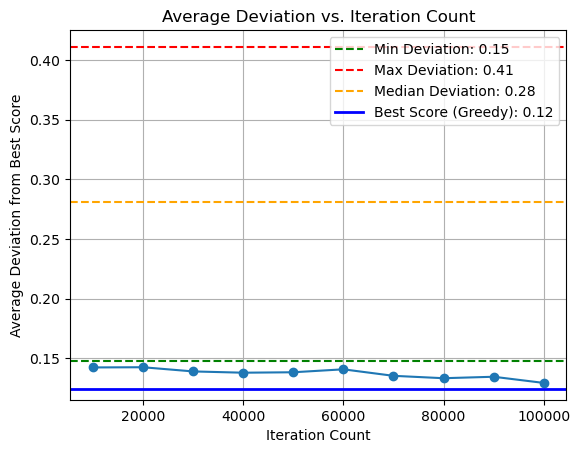
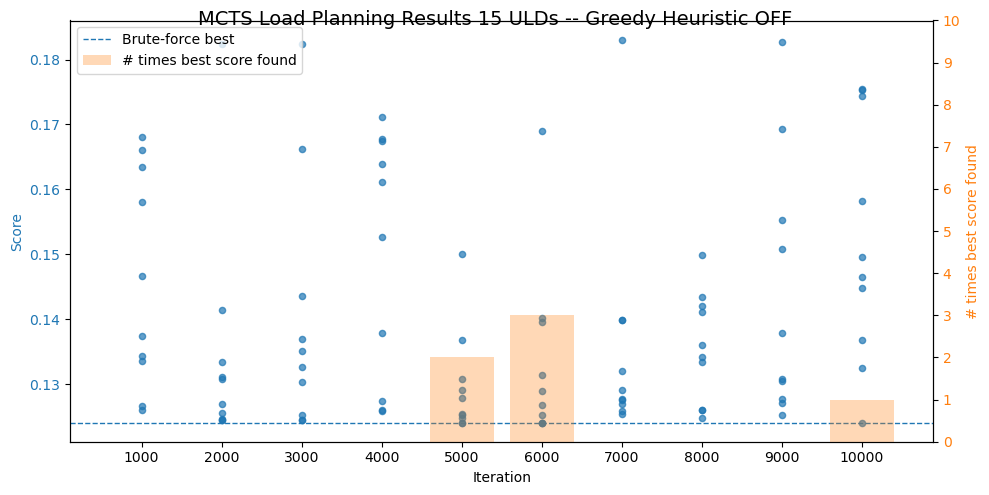
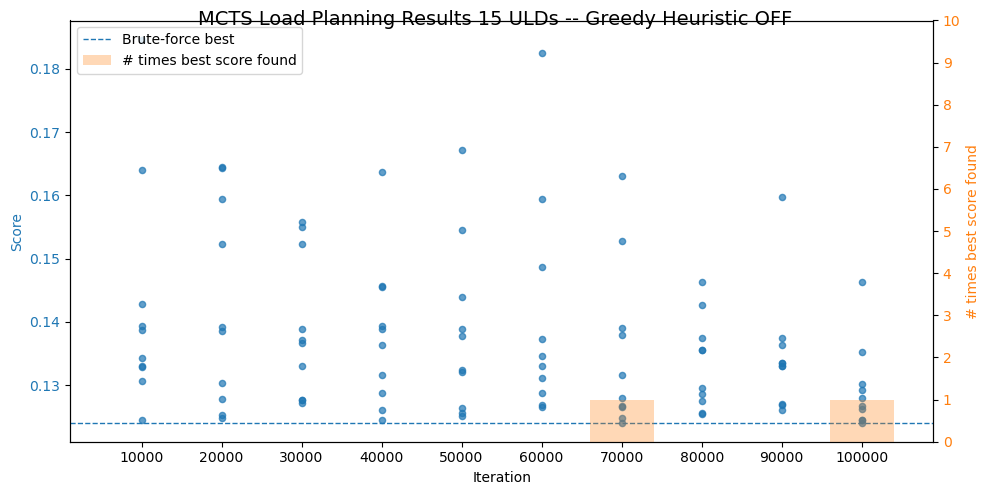
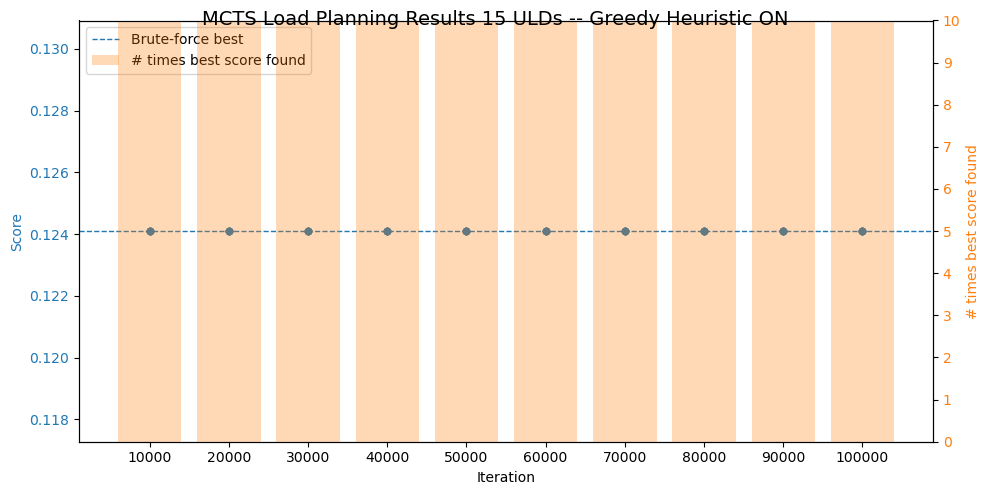
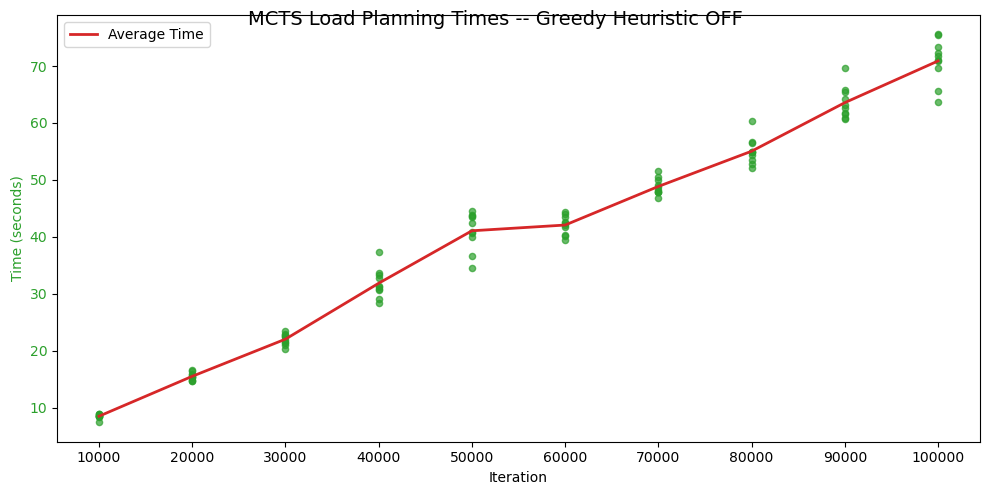